In [1]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats
import pandas as pd
from sklearn.metrics import roc_curve, auc

In [2]:
#pmt details
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 303.3k 100 303.3k   0      0 579.0k      0                              0
100 303.3k 100 303.3k   0      0 578.9k      0                              0
100 303.3k 100 303.3k   0      0 578.7k      0                              0


In [3]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))

def simulate_uniform_signals(num_signals=1000, photons=10_000):
    """Simulate signals uniformly distributed in the TPC"""
    angles = np.random.uniform(0, 2*np.pi, num_signals)
    radii = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy = np.column_stack((radii * np.cos(angles), radii * np.sin(angles)))
    return simulate_signal(xy, photons), xy

def simulate_uniform_double_signals(num_signals=1000, photons=10_000):
    """Simulate double scatters that are uniformly distributed"""
    angle1 = np.random.uniform(0, 2*np.pi, num_signals)
    radius1 = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy1 = np.column_stack((radius1 * np.cos(angle1), radius1 * np.sin(angle1)))
    angle2 = np.random.uniform(0, 2*np.pi, num_signals)
    radius2 = np.sqrt(np.random.uniform(0, tpc_radius**2, num_signals))
    xy2 = np.column_stack((radius2 * np.cos(angle2), radius2 * np.sin(angle2)))
    signal1 = simulate_signal(xy1, photons)
    signal2 = simulate_signal(xy2, photons)
    return signal1 + signal2, xy1, xy2

def simulate_double_signal_constrained_parameters(num_signals=1000, photons=10_000, distance=10, ratio=0.5):
    """Simulate a double scatter signal with a fixed distance and a fixed signal ratio between the signals"""
    
    signal1 = []
    signal2 = []
    true_xy1 = []
    true_xy2 = []
    while len(signal1) < num_signals:
        angle1 = np.random.uniform(0, 2*np.pi)
        radius1 = np.sqrt(np.random.uniform(0, (tpc_radius)**2))
        xy1 = np.column_stack((radius1 * np.cos(angle1), radius1 * np.sin(angle1)))
        angle2 = np.random.uniform(0, 2*np.pi)
        xy2 = xy1 + np.column_stack((distance * np.cos(angle2), distance * np.sin(angle2)))
        # Accept if xy2 is withing TPC
        if np.linalg.norm(xy2, axis=1) < tpc_radius:
            signal1.append(simulate_signal(xy1, ratio * photons).squeeze())      # (127,)
            signal2.append(simulate_signal(xy2, (1-ratio) * photons).squeeze())
            true_xy1.append(xy1.squeeze())
            true_xy2.append(xy2.squeeze())
    return np.array(signal1) + np.array(signal2), np.array(true_xy1), np.array(true_xy2)

Single scatter hypothesis model and optimization

In [4]:
# Define loss function for single scatter hypothesis
def loss_function(xy, signal):
    """Negative log-likelihood of observing signal given mean response at xy. The log likelihood is defined as the sum of the log of the Poisson probabilities for each PMT, given the expected signal from the mean response at xy."""
    lce = mean_response(xy.reshape(1, 2)).squeeze()
    expected_signal = 10_000 * lce  # Assuming 10k photons emitted
    # Poisson likelihood
    return -np.sum(signal * np.log(expected_signal + 1e-6) - expected_signal)

# Define single scatter optimizer
from scipy.optimize import minimize
# Single scatter optimizer
def single_scatter_optimizer(signal):
    """Optimizes parameters for single scatter hypothesis,
    taking the highest valued pmt as initial guess and
    then running a local optimizer"""

    pmt_high=np.argmax(signal)
    initial_guess = pmt_positions[pmt_high]
    result = minimize(lambda xy: loss_function(xy, signal), initial_guess, bounds=[(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius)])
    return result.x

Double scatter hypothesis model and optimization

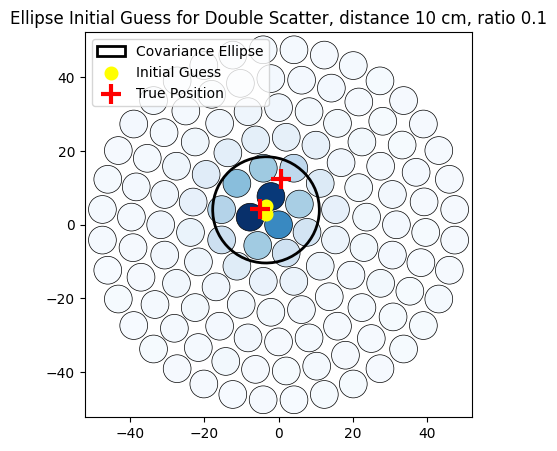

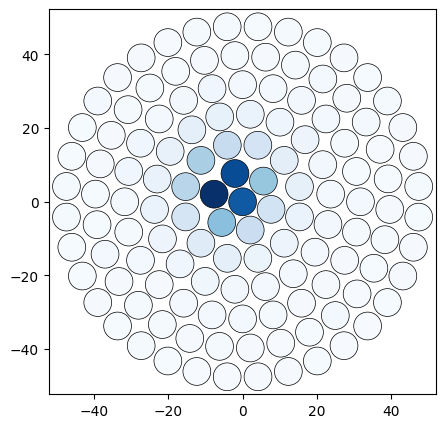

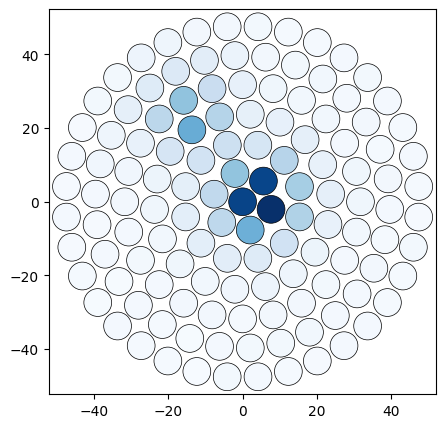

In [11]:
#double scatter optimizer
def double_scatter_initial_guess(signal):
    """Optimizes parameters for double scatter hypothesis, using ellipse foci and 50/50 split of signal as initial guess,
    with plotting of the PMT array and the optimization result. That means varying 5 parameters: x1, y1, x2, y2, and the split ratio of the signal between the two scatters.
    """
    # 2D weighted covariance matrix
    weights = signal / signal.sum()
    x_mean = np.sum(weights * pmt_positions[:, 0])
    y_mean = np.sum(weights * pmt_positions[:, 1])

    dx = pmt_positions[:, 0] - x_mean
    dy = pmt_positions[:, 1] - y_mean

    cov_xx = np.sum(weights * dx**2)
    cov_yy = np.sum(weights * dy**2)
    cov_xy = np.sum(weights * dx * dy)

    cov = np.array([[cov_xx, cov_xy],
                [cov_xy, cov_yy]])

    #Eigendecomposition gives the ellipse axes and rotation
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Semi-axes are sqrt of eigenvalues, angle from principal eigenvector
    a = np.sqrt(eigenvalues[1])  # semi-major
    b = np.sqrt(eigenvalues[0])  # semi-minor
    angle_deg = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))

    # Foci lie along the major axis at distance c from center
    c = np.sqrt(a**2 - b**2)
    major_axis = eigenvectors[:, 1]  # principal eigenvector
    focus1 = (x_mean + c * major_axis[0], y_mean + c * major_axis[1])
    focus2 = (x_mean - c * major_axis[0], y_mean - c * major_axis[1])
    initial_guess = [focus1[0], focus1[1], focus2[0], focus2[1], 0.5]  # x1, y1, x2, y2, split ratio

    return initial_guess, focus1, focus2, (x_mean, y_mean), a, b, angle_deg

def double_scatter_loss(params, signal):
    """Loss function for double scatter hypothesis, given parameters and observed signal. The parameters are x1, y1, x2, y2, and split ratio of the signal between the two scatters."""
    x1, y1, x2, y2, split_ratio = params
    xy1 = np.array([[x1, y1]])
    xy2 = np.array([[x2, y2]])
    expected_signal1 = 10_000 * mean_response(xy1).squeeze() * split_ratio
    expected_signal2 = 10_000 * mean_response(xy2).squeeze() * (1 - split_ratio)
    expected_signal = expected_signal1 + expected_signal2
    return -np.sum(signal * np.log(expected_signal + 1e-6) - expected_signal)

def double_scatter_optimizer(signal):
    """Optimizes parameters for double scatter hypothesis, using the initial guess from the ellipse method."""
    initial_guess, focus1, focus2, center, a, b, angle_deg = double_scatter_initial_guess(signal)
    bounds = [(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius), (0.01, 0.99)]
    result = minimize(lambda params: double_scatter_loss(params, signal), initial_guess, bounds=bounds)
    return result

def ellipse_example_plotting(signal, true_xy1, true_xy2, figsize=(5, 5)):
    """Example plotting of the PMT array, the weighted covariance ellipse, and the initial guess for the double scatter optimizer."""
    initial_guess, focus1, focus2, center, a, b, angle_deg = double_scatter_initial_guess(signal)

    plt.figure(figsize=figsize)   # <-- sets the whole-figure size, in inches

    # make PMTs
    plt.scatter(*pmt_positions.T, c=signal, cmap='Blues', s=400, vmin=0, edgecolors='black', linewidths=0.5)
    # draw ellipse
    ellipse = plt.matplotlib.patches.Ellipse(center, 2*a, 2*b, angle=angle_deg, edgecolor='black', facecolor='none', lw=2, label='Covariance Ellipse')
    plt.gca().add_patch(ellipse)
    # draw foci
    plt.scatter(*focus1, c='yellow', marker='.', s=200, zorder=5, linewidths=3, label='Initial Guess')
    plt.scatter(*focus2, c='yellow', marker='.', s=200, zorder=5, linewidths=3)
    #include true positions
    plt.scatter(*true_xy1, c='red', marker='+', s=200, zorder=5, linewidths=3, label='True Position')
    plt.scatter(*true_xy2, c='red', marker='+', s=200, zorder=5, linewidths=3)

    plt.title('Ellipse Initial Guess for Double Scatter, distance 10 cm, ratio 0.1')
    plt.legend()
    plt.show()

#usage
combined_signal, true_xy1, true_xy2 = simulate_double_signal_constrained_parameters(
    num_signals=5, photons=10_000, distance=10, ratio=0.1
)
ellipse_example_plotting(combined_signal[0], true_xy1[0], true_xy2[0])

#random hit pattern plotting

def hit_pattern_plot(signal):
    """Plot a hit pattern as an example."""
    plt.figure(figsize=(5, 5))
    plt.scatter(*pmt_positions.T, c=signal, cmap='Blues', s=400, vmin=0, edgecolors='black', linewidths=0.5)
    plt.show()

signal, xy1, xy2 = simulate_double_signal_constrained_parameters(num_signals=1, photons=10_000, distance=0, ratio=0.5)
hit_pattern_plot(signal[0])

signal, xy1, xy2 = simulate_double_signal_constrained_parameters(num_signals=1, photons=10_000, distance=30, ratio=0.3)
hit_pattern_plot(signal[0])

Calculating statistics and performing selection

Since there is a persistence of false positives, now creating a database to sift through results